# GMM Diffusion: Salience-Guided Sampling

This notebook runs experiments comparing:
- Baseline DDPM sampling
- Salience-guided sampling with `TailnessGlobalPhi`
- Salience-guided sampling with `TailnessLooPhi`
- Salience-guided sampling with `DiversityPhi`

All sampler and phi logic lives in the `salience_diffusion` package.
This notebook only configures experiments and visualises results.

In [40]:
import sys
sys.path.insert(0, '..')   # so we can import salience_diffusion from notebooks/

import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# -- Package imports --
from diffusion.model import MLP
from diffusion.scheduler import NoiseScheduler, reverse_step
from salience.sampler import SalientSampler
from salience.phi import DiversityPhi, TailnessLooPhi, TailnessGlobalPhi
from salience.tailness_sampler import sample_tailness_loo, sample_tailness_global
from experiments.gmm import GaussianMixture, gmm_pdf_contour
from experiments.evaluation import (
    scatter_samples, compare_samplers, plot_distance_histogram,
    distance_to_nearest_mode, summarise_samples,
)
from experiments.checkpoints import load_model, load_base_noise, save_checkpoint
from experiments.comparison import save_samples, save_figure, make_comparison_figure

# -- Device --
if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')
print(f'Using device: {DEVICE}')

OUTPUTS_DIR = Path('../outputs')
OUTPUTS_DIR.mkdir(exist_ok=True)

Using device: mps


## 1. Define the GMM

In [41]:
torch.manual_seed(2024)

prior_gmm = GaussianMixture(
    mus=[
        torch.tensor([8.0, 8.0]),
        torch.tensor([2.0, 2.0]),
    ],
    covs=[
        torch.tensor([1.0, 1.0]),
        torch.tensor([1.0, 1.0]),
    ],
    weights=[1.0, 1.0],
    device=DEVICE,
)

MODE_CENTRES = np.array([
    [8.0, 8.0],
    [2.0, 2.0],
])

## 2. Train (or load) the denoising model

In [42]:
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from tqdm.auto import tqdm

MODEL_PATH = OUTPUTS_DIR / 'model.pt'
NOISE_PATH  = OUTPUTS_DIR / 'base_noise.pt'
T = 1000

noise_scheduler = NoiseScheduler(num_timesteps=T).to(DEVICE)

if MODEL_PATH.exists():
    model = load_model(MODEL_PATH, device=DEVICE)
    print('Loaded existing model.')
else:
    # Training
    data = prior_gmm.sample(50_000).float()
    loader = DataLoader(TensorDataset(data), shuffle=True, batch_size=32)

    model = MLP(
        hidden_size=128, hidden_layers=3, emb_size=128,
        time_emb='sinusoidal', input_emb='identity',
    ).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

    for epoch in tqdm(range(200)):
        model.train()
        for (x0,) in loader:
            x0 = x0.to(DEVICE)
            t = torch.randint(0, T, (x0.shape[0],), device=DEVICE).long()
            noise = torch.randn_like(x0)
            noisy = noise_scheduler.add_noise(x0, noise, t)
            loss = F.mse_loss(model(noisy, t), noise)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

    save_checkpoint(model, MODEL_PATH)
    model.eval()
    print('Trained and saved model.')

Loaded existing model.


In [43]:
# Save or load fixed base noise for reproducible comparisons
if NOISE_PATH.exists():
    base_noise = load_base_noise(NOISE_PATH, device=DEVICE)
    print('Loaded base noise.')
else:
    base_noise = torch.randn((512, 2), device=DEVICE)
    torch.save(base_noise.cpu(), NOISE_PATH)
    print('Generated and saved base noise.')

N_SAMPLES = 256
x_init = base_noise[:N_SAMPLES].to(DEVICE)

Loaded base noise.


## 3. Baseline DDPM

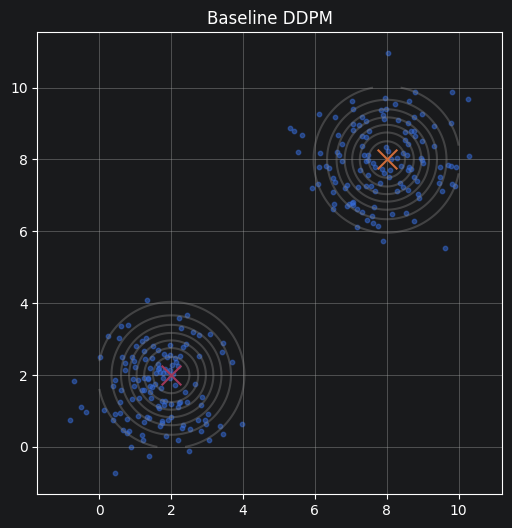

In [11]:
@torch.no_grad()
def sample_ddpm(model, scheduler, x_init):
    x = x_init.clone()
    for t in reversed(range(len(scheduler))):
        x = reverse_step(model, scheduler, x, t)
    return x

x0_base = sample_ddpm(model, noise_scheduler, x_init)
scatter_samples(x0_base, gmm=prior_gmm, modes=MODE_CENTRES, title='Baseline DDPM')
plt.show()

## 4. Tailness sampling (shared Gaussian)

In [8]:
# x0_tail_global = sample_tailness_global(
#     model=model,
#     scheduler=noise_scheduler,
#     x_init=x_init,
#     K=16,
#     cov_reg=1e-4,
#     verbose=True,
# )
# scatter_samples(x0_tail_global, gmm=prior_gmm, modes=MODE_CENTRES, title='Tailness (shared Gaussian)')
# plt.show()

## 5. Evaluation

In [9]:
# sample_dict = {
#     'DDPM': x0_base.detach().cpu().numpy(),
#     'Tailness (global)': x0_tail_global.detach().cpu().numpy(),
# }
#
# fig = plot_distance_histogram(sample_dict, modes=MODE_CENTRES)
# plt.show()

## 6. DiversityPhi

DiversityPhi requires a library of previously generated samples.
Here we use the baseline DDPM samples as the library — we are then
asking the salient sampler to generate samples that are dissimilar
from what DDPM already produced.

In [5]:
phi_diversity = DiversityPhi(use_tweedie=True)
diversity_sampler = SalientSampler(
    model=model,
    scheduler=noise_scheduler,
    phi=phi_diversity,
    K=8,
    device=DEVICE,
    guidance_frequency=10
)

context = {
    'library': x0_base.detach(),
    'max_library_size': 128,   # subsample to bound Jacobian size
    "model": model,
    "scheduler": noise_scheduler,
}

x0_diverse_offline = diversity_sampler.sample_resampling_guided(x_init, context=context, verbose=True)
scatter_samples(x0_diverse_offline, gmm=prior_gmm, modes=MODE_CENTRES, title='DiversityPhi')
plt.show()

NameError: name 'x0_base' is not defined

DiversityPhi can also be run sequentially, with the initial library of generated samples left empty. This way, the initial sampler runs as DDPM, and from there on uses salience-sensitive sampling to avoid localities that would generate similar samples.

  t = 900
  t = 800
  t = 700
  t = 600
  t = 500
  t = 400
  t = 300
  t = 200
  t = 100
  t = 0
  t = 900
  t = 800
  t = 700
  t = 600
  t = 500
  t = 400
  t = 300
  t = 200
  t = 100
  t = 0
  t = 900
  t = 800
  t = 700
  t = 600
  t = 500
  t = 400
  t = 300
  t = 200
  t = 100
  t = 0
  t = 900
  t = 800
  t = 700
  t = 600
  t = 500
  t = 400
  t = 300
  t = 200
  t = 100
  t = 0
  t = 900
  t = 800
  t = 700
  t = 600
  t = 500
  t = 400
  t = 300
  t = 200
  t = 100
  t = 0
  t = 900
  t = 800
  t = 700
  t = 600
  t = 500
  t = 400
  t = 300
  t = 200
  t = 100
  t = 0
  t = 900
  t = 800
  t = 700
  t = 600
  t = 500
  t = 400
  t = 300
  t = 200
  t = 100
  t = 0
  t = 900
  t = 800
  t = 700
  t = 600
  t = 500
  t = 400
  t = 300
  t = 200
  t = 100
  t = 0
  t = 900
  t = 800
  t = 700
  t = 600
  t = 500
  t = 400
  t = 300
  t = 200
  t = 100
  t = 0
  t = 900
  t = 800
  t = 700
  t = 600
  t = 500
  t = 400
  t = 300
  t = 200
  t = 100
  t = 0
  t = 900
  t = 800


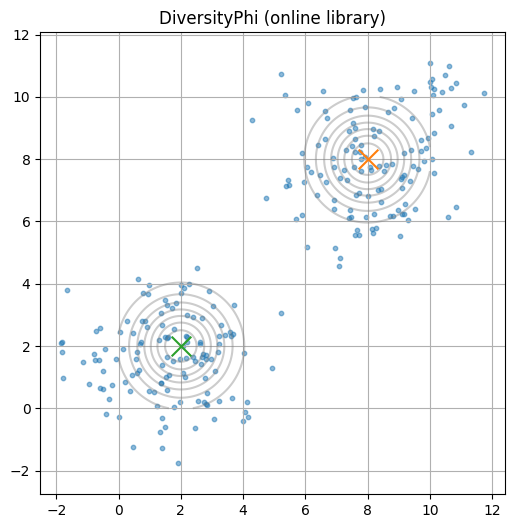

In [6]:
phi_diversity = DiversityPhi(use_tweedie=True)
diversity_sampler = SalientSampler(
    model=model,
    scheduler=noise_scheduler,
    phi=phi_diversity,
    K=8,
    device=DEVICE,
    guidance_frequency=10,
)

num_samples = x_init.shape[0]

library = []
generated = []

for i in range(num_samples):
    if len(library) == 0:
        library_tensor = torch.empty((0, x_init.shape[1]), device=DEVICE)
    else:
        library_tensor = torch.cat(library, dim=0)

    context = {
        "library": library_tensor,
        "max_library_size": 128,
        "model": model,
        "scheduler": noise_scheduler,
    }

    x0_i = diversity_sampler.sample_resampling_guided(
        x_init[i:i+1],
        context=context,
        verbose=True,
    )

    x0_i = x0_i.detach()
    generated.append(x0_i)
    library.append(x0_i)

x0_diverse = torch.cat(generated, dim=0)

scatter_samples(
    x0_diverse,
    gmm=prior_gmm,
    modes=MODE_CENTRES,
    title="DiversityPhi (online library)"
)
plt.show()

In [5]:
# ---------------------------------------------------------------------------
# Output directories
# ---------------------------------------------------------------------------
SAMPLES_DIR = OUTPUTS_DIR / "sampling_results" / "samples"
PLOTS_DIR   = OUTPUTS_DIR / "sampling_results" / "plots"


In [8]:

# ---------------------------------------------------------------------------
# Save samples
# ---------------------------------------------------------------------------
save_samples(x0_base,    name="ddpm_baseline",       root=SAMPLES_DIR)
save_samples(x0_diverse, name="diversity_phi_online", root=SAMPLES_DIR)

# ---------------------------------------------------------------------------
# Build and save the comparison figure
# ---------------------------------------------------------------------------
fig = make_comparison_figure(
    sample_dict={
        "DDPM baseline":       x0_base,
        "DiversityPhi (online)": x0_diverse,
    },
    gmm=prior_gmm,
    modes=MODE_CENTRES,
    suptitle="DDPM vs DiversityPhi: salience-guided sampling",
)

save_figure(fig, name="comparison_ddpm_vs_diversity_phi_online", root=PLOTS_DIR)
plt.show()

## 6.1 DiversityPhi - Particle Sampling inspired
Rather than using a pre-existing library of complete samples, apply DiversityPhi in parallel to n noisy samples


  t = 999
  t = 998
  t = 997
  t = 996
  t = 995
  t = 994
  t = 993
  t = 992
  t = 991
  t = 990
  t = 989
  t = 988
  t = 987
  t = 986
  t = 985
  t = 984
  t = 983
  t = 982
  t = 981
  t = 980
  t = 979
  t = 978
  t = 977
  t = 976
  t = 975
  t = 974
  t = 973
  t = 972
  t = 971
  t = 970
  t = 969
  t = 968
  t = 967
  t = 966
  t = 965
  t = 964
  t = 963
  t = 962
  t = 961
  t = 960
  t = 959
  t = 958
  t = 957
  t = 956
  t = 955
  t = 954
  t = 953
  t = 952
  t = 951
  t = 950
  t = 949
  t = 948
  t = 947
  t = 946
  t = 945
  t = 944
  t = 943
  t = 942
  t = 941
  t = 940
  t = 939
  t = 938
  t = 937
  t = 936
  t = 935
  t = 934
  t = 933
  t = 932
  t = 931
  t = 930
  t = 929
  t = 928
  t = 927
  t = 926
  t = 925
  t = 924
  t = 923
  t = 922
  t = 921
  t = 920
  t = 919
  t = 918
  t = 917
  t = 916
  t = 915
  t = 914
  t = 913
  t = 912
  t = 911
  t = 910
  t = 909
  t = 908
  t = 907
  t = 906
  t = 905
  t = 904
  t = 903
  t = 902
  t = 901
  t = 900


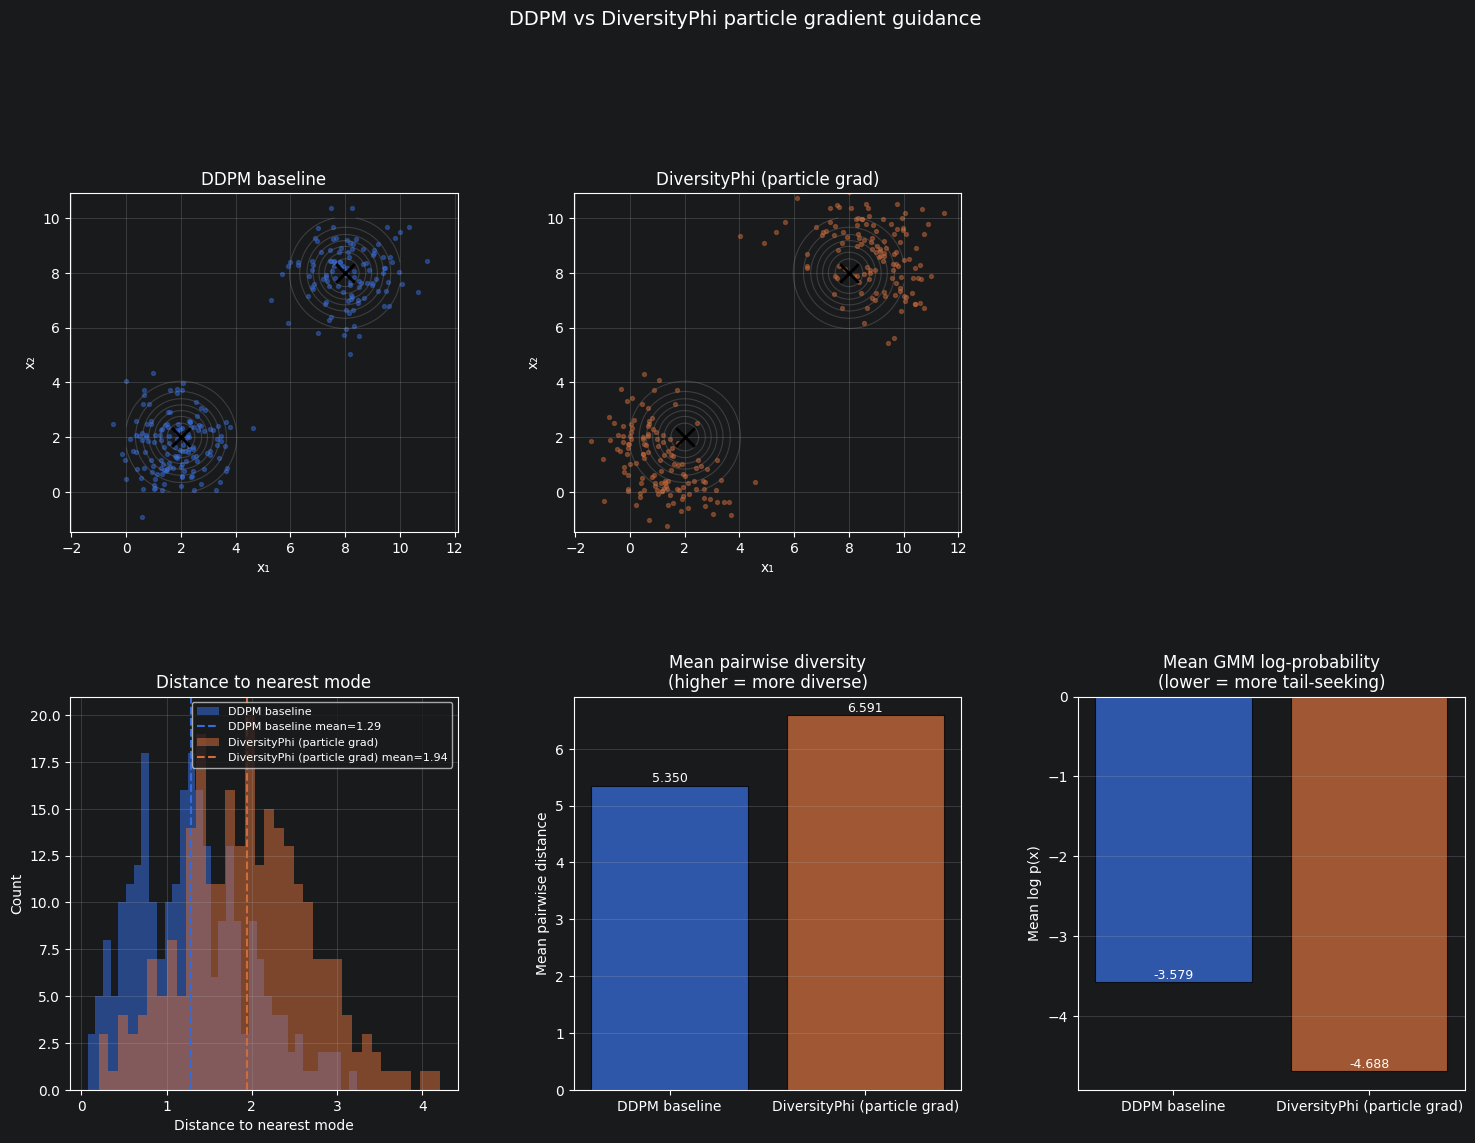

In [12]:
%load_ext autoreload
%autoreload 2
from salience.phi import DiversityPhi
from salience.sampler import SalientSampler
from experiments.comparison import make_comparison_figure, save_figure, save_samples

# --- Setup ---
phi_diversity = DiversityPhi(use_tweedie=False)
sampler = SalientSampler(
    model=model,
    scheduler=noise_scheduler,
    phi=phi_diversity,
    device=DEVICE,
    guidance_frequency=1,
)

# --- Sample ---
x0_particle_grad = sampler.sample_particle_grad_guided(
    x_init[:256],
    guidance_scale=1.0,
    verbose=True,
)

# --- Save samples ---
save_samples(
    x0_particle_grad,
    name="diversity_phi_particle_grad",
    root=SAMPLES_DIR,
)

x0_base = torch.load(SAMPLES_DIR / "baselines" / "ddpm_baseline.pt")

# --- Comparison figure ---
fig = make_comparison_figure(
    sample_dict={
        "DDPM baseline":          x0_base,
        "DiversityPhi (particle grad)": x0_particle_grad,
    },
    gmm=prior_gmm,
    modes=MODE_CENTRES,
    suptitle="DDPM vs DiversityPhi particle gradient guidance",
)

save_figure(
    fig,
    name="comparison_ddpm_vs_diversity_phi_particle_grad",
    root=PLOTS_DIR,
)
plt.show()

## 7. ScoreNormPhi

Resampling Guided Reverse Diffusion:

In [14]:
from salience.phi import ScoreNormPhi

phi_score = ScoreNormPhi()
sampler = SalientSampler(
    model=model,
    scheduler=noise_scheduler,
    phi=phi_score,
    K=8,
    device=DEVICE,
    guidance_frequency=10,
    batched = True,
)

context = {"model": model, "scheduler": noise_scheduler}
x0_score = sampler.sample_resampling_guided(x_init, context=context, verbose=True)

KeyboardInterrupt: 

In [7]:
save_samples(x0_score, name="score_norm_phi", root=SAMPLES_DIR)

Saved samples -> ../outputs/sampling_results/samples/score_norm_phi.pt
Saved samples -> ../outputs/sampling_results/samples/score_norm_phi.npy


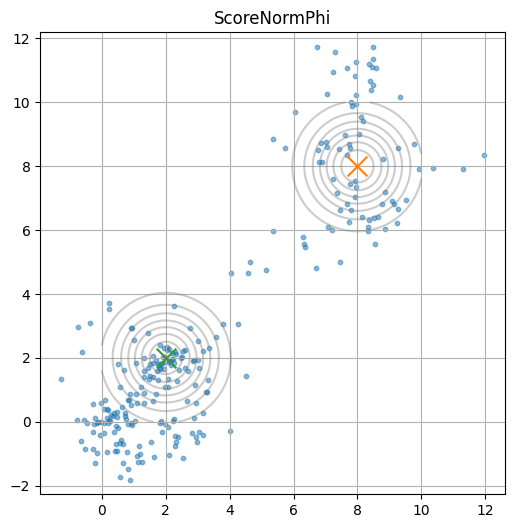

In [8]:
scatter_samples(
    x0_score,
    gmm=prior_gmm,
    modes=MODE_CENTRES,
    title="ScoreNormPhi"
)
plt.show()


Metric                         DDPM baseline  ScoreNormPhi
-------------------------------------------------------
Mean dist to nearest mode          1.2902
Mean dist to nearest mode          1.8256
Mean pairwise diversity            5.3499
Mean pairwise diversity            5.7275
Mean GMM log-prob                 -3.5785
Mean GMM log-prob                 -4.7144



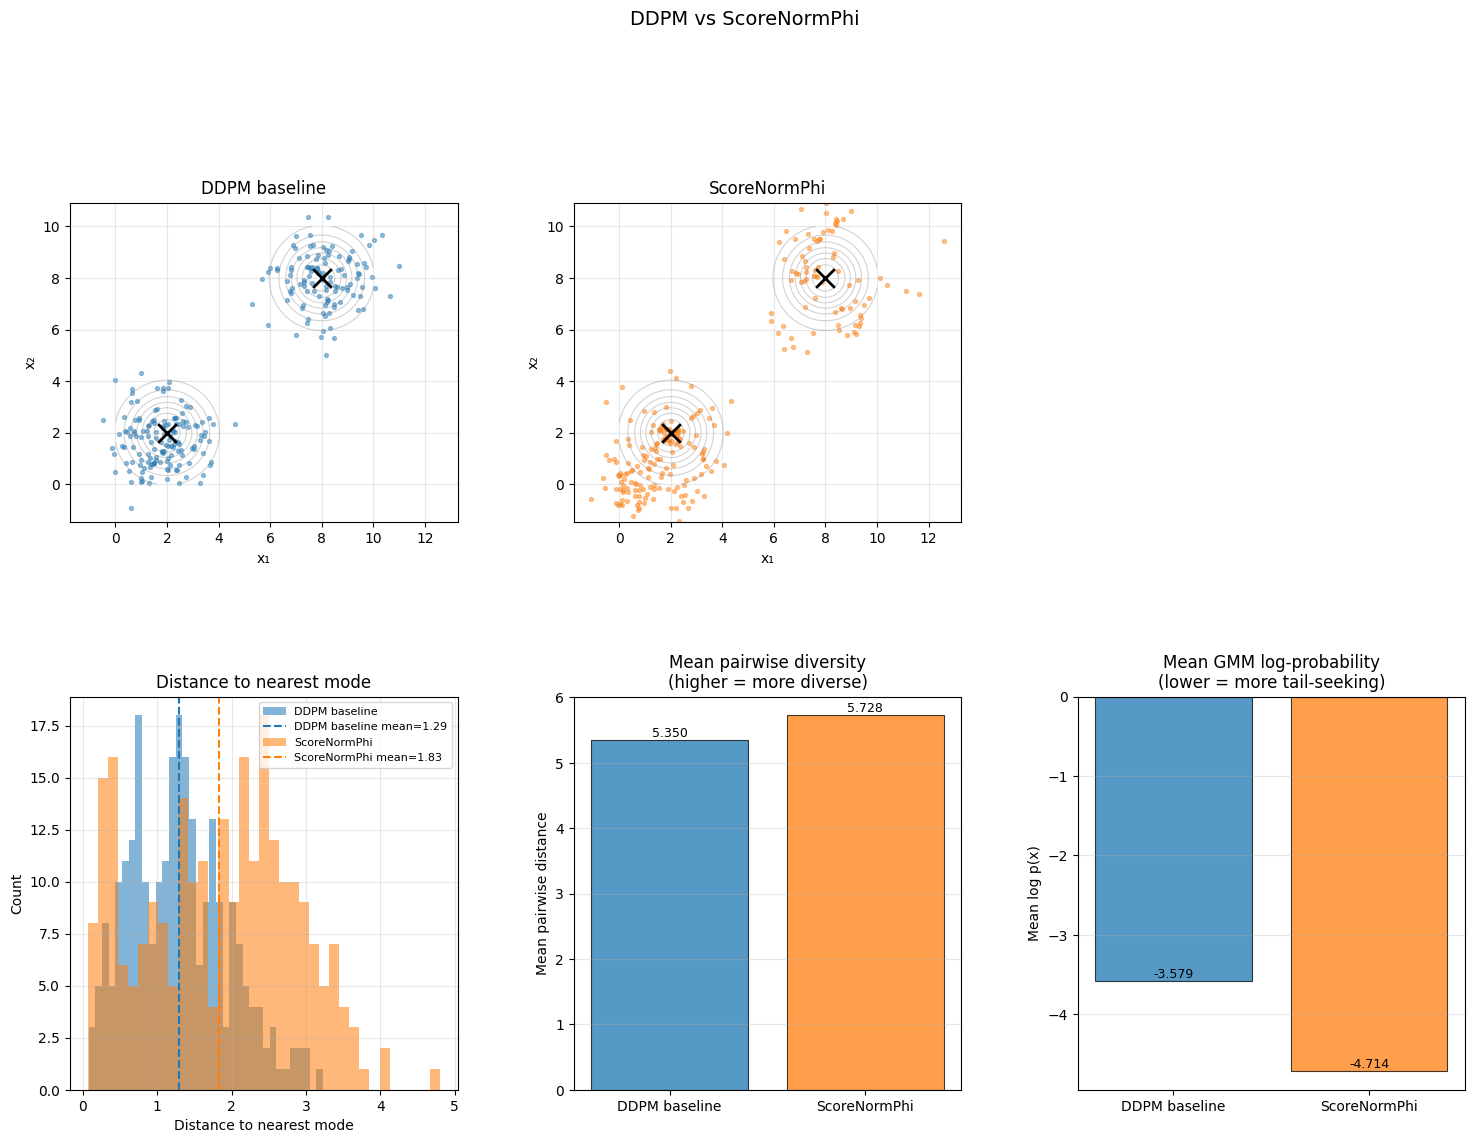

In [8]:
fig = make_comparison_figure(
    sample_dict={
        "DDPM baseline": x0_base,
        "ScoreNormPhi": x0_score,
    },
    gmm=prior_gmm,
    modes=MODE_CENTRES,
    suptitle="DDPM vs ScoreNormPhi",
)


Gradient Guided Reverse Diffusion

In [15]:
from salience.phi import ScoreNormPhi

phi_score = ScoreNormPhi()
sampler = SalientSampler(
    model=model,
    scheduler=noise_scheduler,
    phi=phi_score,
    device=DEVICE,
    guidance_frequency=1,
    batched = True,
)

context = {"model": model, "scheduler": noise_scheduler}

x0_guided = sampler.sample_grad_guided(
    x_init,
    guidance_scale=1.0,
    context=context,
    verbose=True,
)

  t = 900
  t = 800
  t = 700
  t = 600
  t = 500
  t = 400
  t = 300
  t = 200
  t = 100
  t = 0


In [15]:
save_samples(x0_guided, name="score_norm_phi_grad", root=SAMPLES_DIR)

Saved samples -> ../outputs/sampling_results/samples/score_norm_phi_grad.pt
Saved samples -> ../outputs/sampling_results/samples/score_norm_phi_grad.npy



Metric                         DDPM baseline  ScoreNormGradient
-------------------------------------------------------
Mean dist to nearest mode          1.2902
Mean dist to nearest mode          1.4293
Mean pairwise diversity            5.3499
Mean pairwise diversity            5.4839
Mean GMM log-prob                 -3.5785
Mean GMM log-prob                 -3.8515



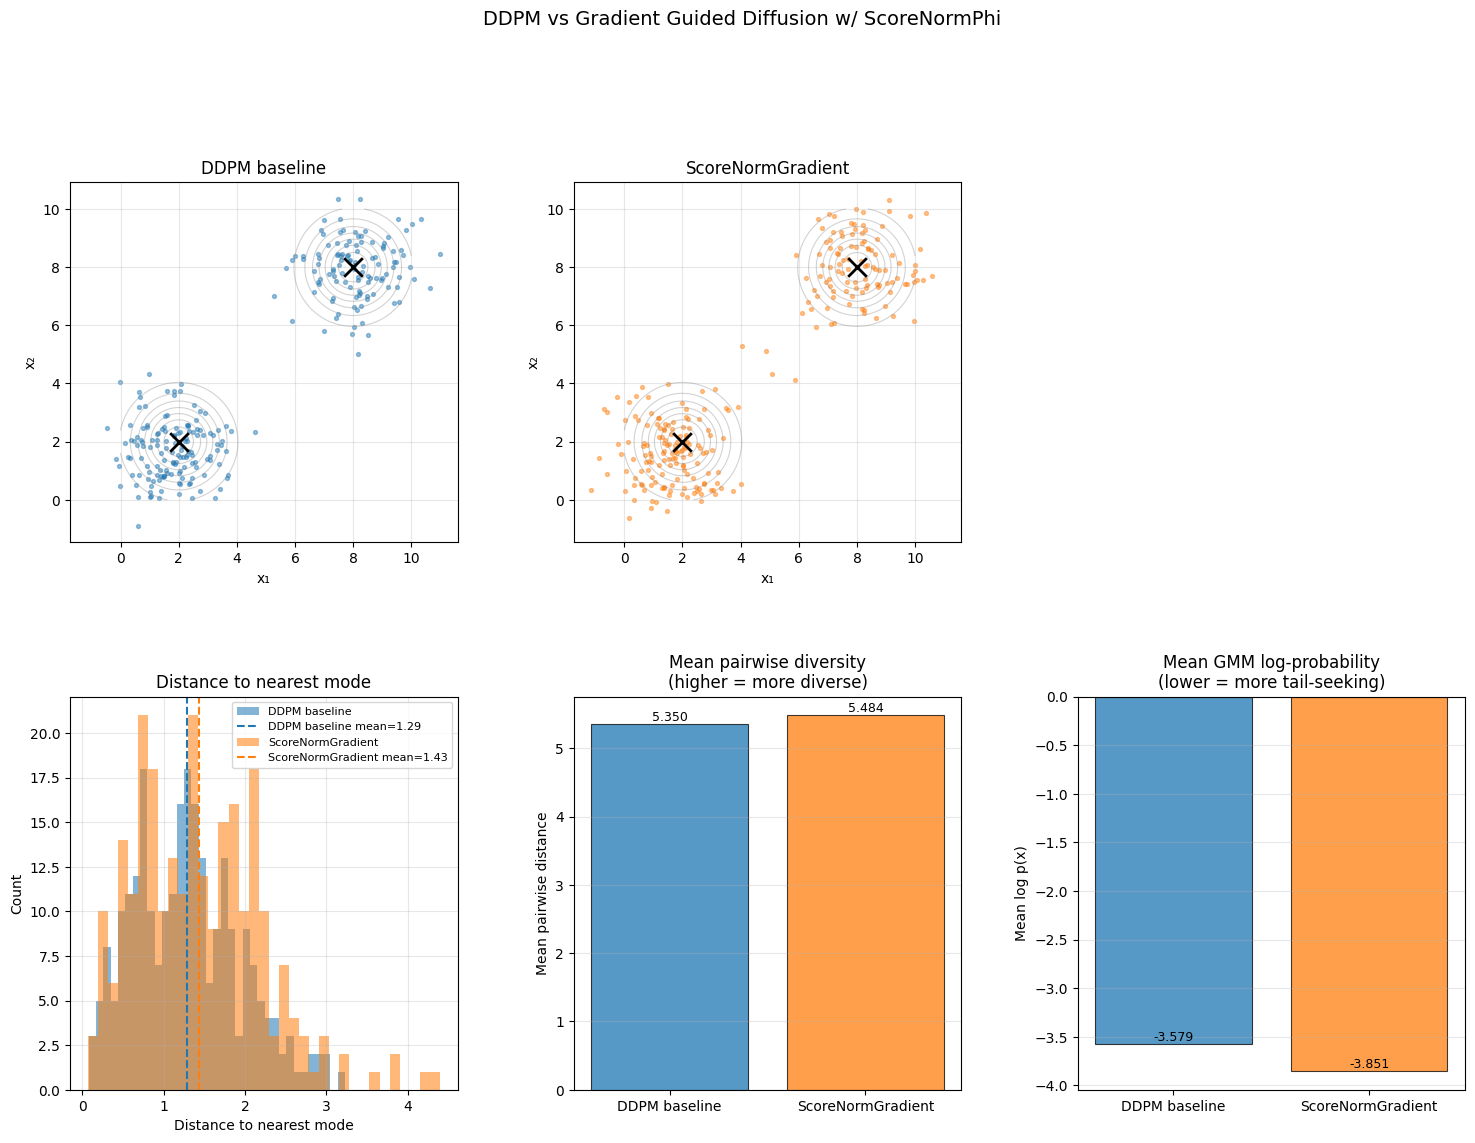

In [20]:
x0_base = torch.load(SAMPLES_DIR / "baselines" /"ddpm_baseline.pt", map_location=DEVICE)

fig = make_comparison_figure(
    sample_dict={
        "DDPM baseline": x0_base,
        "ScoreNormGradient": x0_guided,
    },
    gmm=prior_gmm,
    modes=MODE_CENTRES,
    suptitle="DDPM vs Gradient Guided Diffusion w/ ScoreNormPhi ",
)




In [21]:
save_figure(fig, name="comparison_ddpm_vs_grad_score_norm_phi_2", root=PLOTS_DIR)

Saved figure  -> ../outputs/sampling_results/plots/comparison_ddpm_vs_grad_score_norm_phi_2.png


Salience Mapping

  Computing salience grid at t=900...
  Computing salience grid at t=500...
  Computing salience grid at t=250...
  Computing salience grid at t=50...
Saved figure  -> ../outputs/sampling_results/plots/salience_landscape_score_norm_phi_2.png


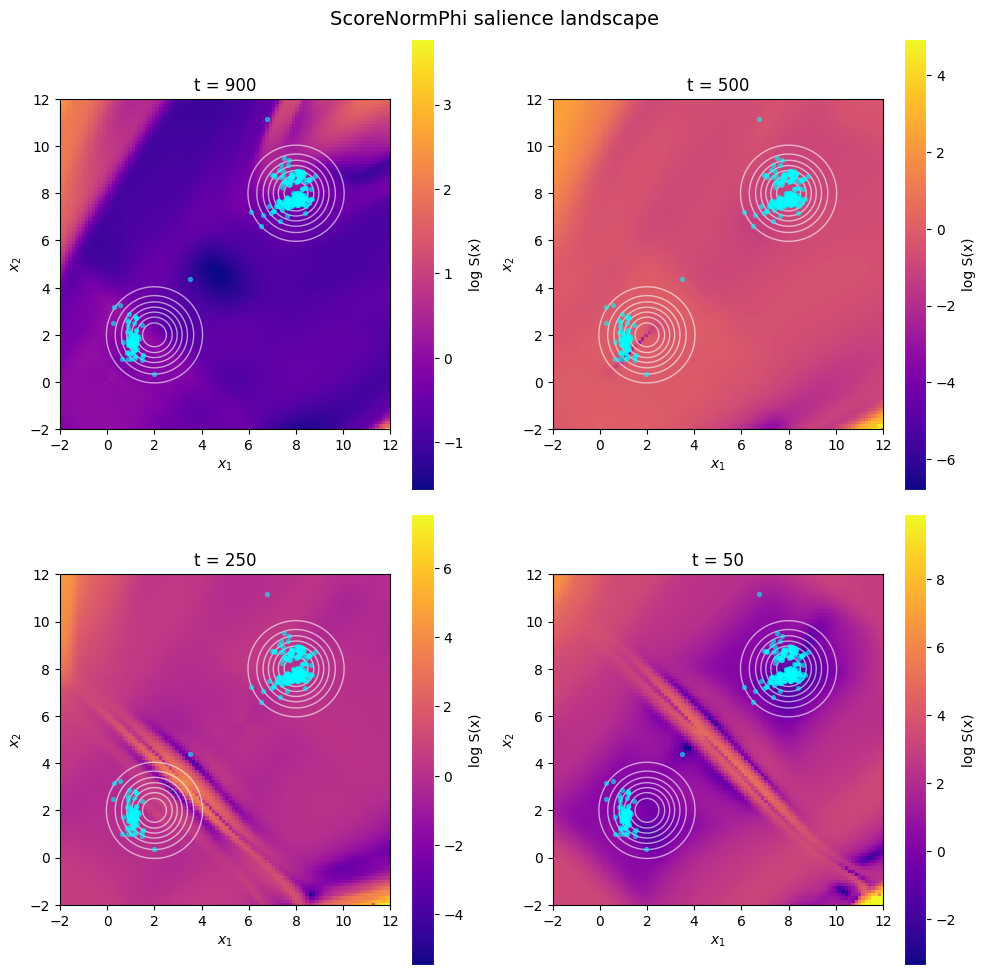

In [58]:
from experiments.visualize_salience import plot_salience_landscape

context = {"model": model, "scheduler": noise_scheduler}

fig = plot_salience_landscape(
    phi=ScoreNormPhi(),
    timesteps=[900, 500, 250, 50],
    context=context,
    gmm=prior_gmm,
    samples=x0_guided,
    device=DEVICE,
    suptitle="ScoreNormPhi salience landscape",
)

save_figure(fig, name="salience_landscape_score_norm_phi_2", root=PLOTS_DIR)
plt.show()

  Computing vector field at t=900...
  Computing vector field at t=500...
  Computing vector field at t=250...
  Computing vector field at t=50...


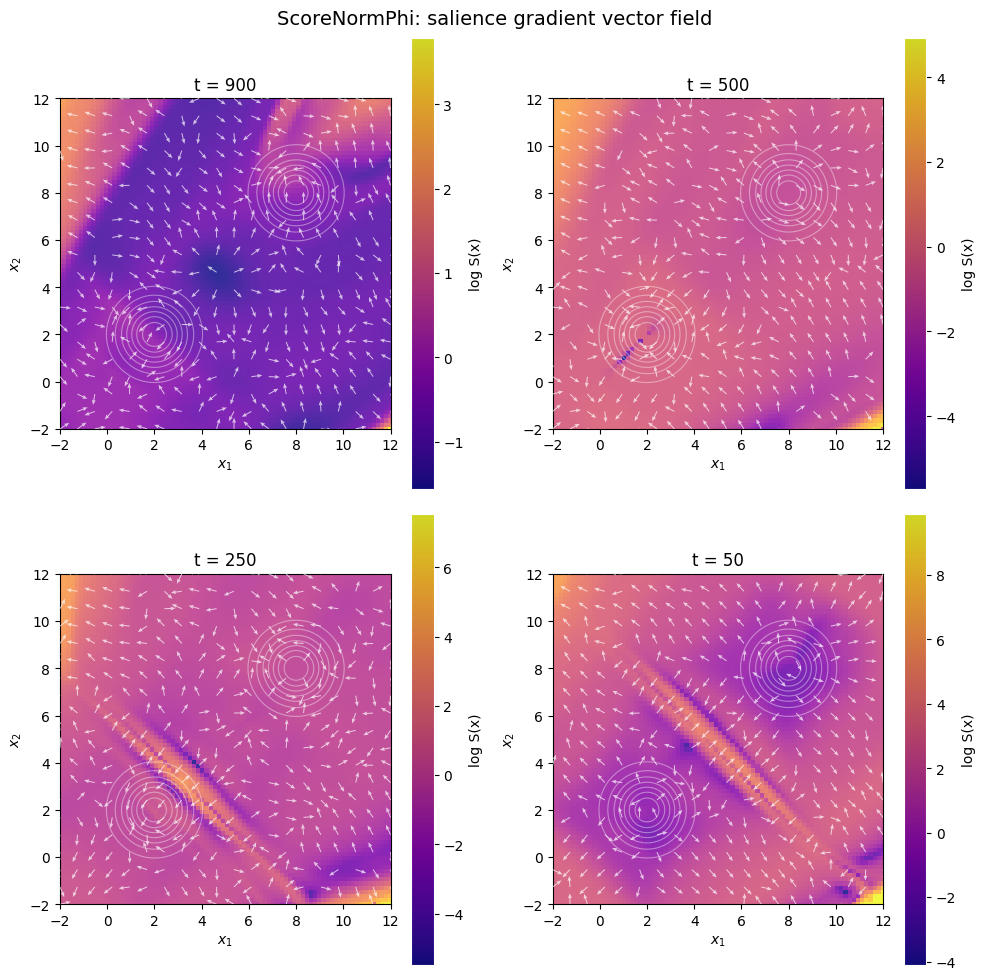

In [59]:
from experiments.visualize_salience import plot_salience_vector_field
from salience.phi import ScoreNormPhi

phi = ScoreNormPhi()
context = {"model": model, "scheduler": noise_scheduler}

fig = plot_salience_vector_field(
    phi=phi,
    timesteps=[900, 500, 250, 50],
    context=context,
    gmm=prior_gmm,
    suptitle="ScoreNormPhi: salience gradient vector field",
    device=DEVICE,
)

  Computing vector field at t=900...
  Computing vector field at t=500...
  Computing vector field at t=250...
  Computing vector field at t=50...


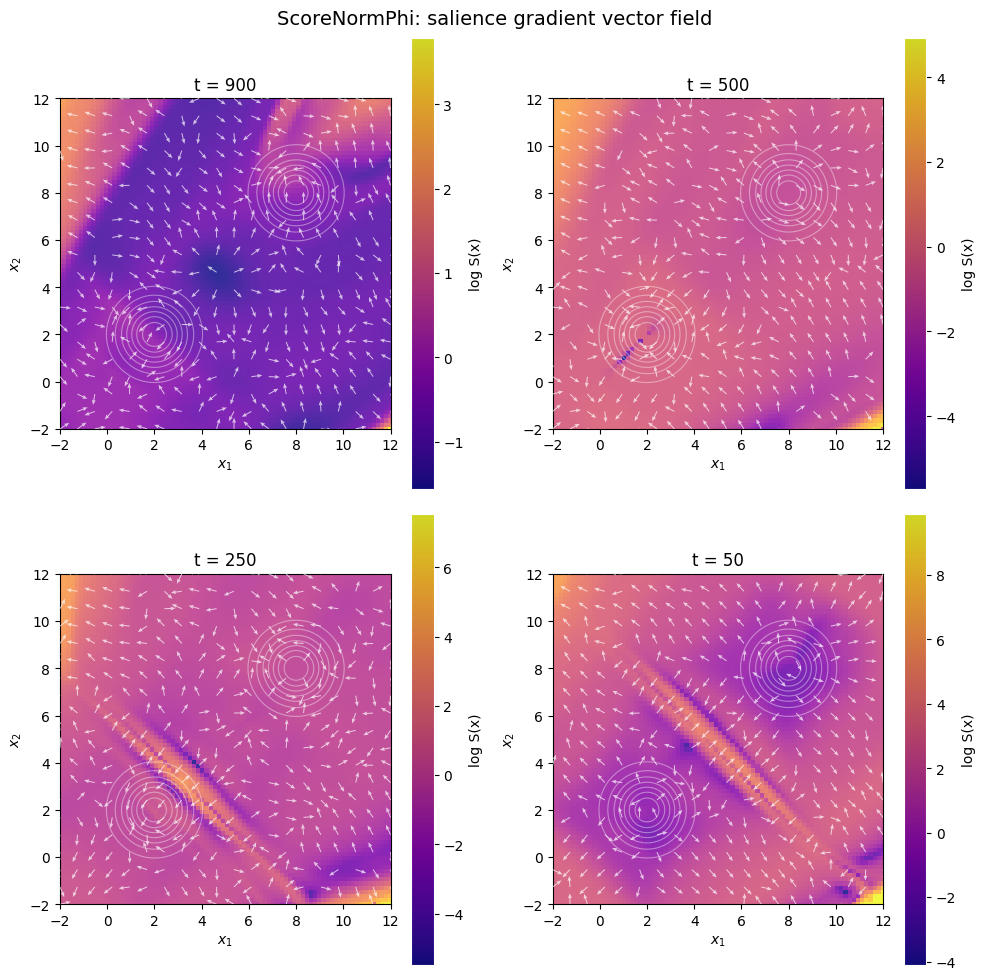

In [62]:
from salience.sampler import SalientSampler
from salience.phi import ScoreNormPhi
from experiments.visualize_salience import (
    sample_with_trajectory_capture,
    plot_salience_vector_field,
)

phi = ScoreNormPhi()
context = {"model": model, "scheduler": noise_scheduler}

sampler = SalientSampler(
    model=model, scheduler=noise_scheduler,
    phi=phi, device=DEVICE, guidance_frequency=1,
)

x0, snaps_guided = sample_with_trajectory_capture(
    sampler=sampler,
    x_T=x_init,
    capture_timesteps=[900, 500, 250, 50],
    guidance_scale=1.0,
    context=context,
)

fig = plot_salience_vector_field(
    phi=phi,
    timesteps=[900, 500, 250, 50],
    context=context,
    gmm=prior_gmm,
    suptitle="ScoreNormPhi: salience gradient vector field",
    device=DEVICE,
)

## 8. ScoreAlignmentPhi: Average of cosine similarity between the score functions of samples across the batch

In [22]:
from salience.phi import ScoreAlignmentPhi

phi_align = ScoreAlignmentPhi()
sampler = SalientSampler(
    model=model,
    scheduler=noise_scheduler,
    phi=phi_align,
    device=DEVICE,
    guidance_frequency=1,
)

context = {"model": model, "scheduler": noise_scheduler}
x0_align = sampler.sample_particle_grad_guided(
    x_init, guidance_scale=1.0, context=context, verbose=True,
)

  t = 999
  t = 998
  t = 997
  t = 996
  t = 995
  t = 994
  t = 993
  t = 992
  t = 991
  t = 990
  t = 989
  t = 988
  t = 987
  t = 986
  t = 985
  t = 984
  t = 983
  t = 982
  t = 981
  t = 980
  t = 979
  t = 978
  t = 977
  t = 976
  t = 975
  t = 974
  t = 973
  t = 972
  t = 971
  t = 970
  t = 969
  t = 968
  t = 967
  t = 966
  t = 965
  t = 964
  t = 963
  t = 962
  t = 961
  t = 960
  t = 959
  t = 958
  t = 957
  t = 956
  t = 955
  t = 954
  t = 953
  t = 952
  t = 951
  t = 950
  t = 949
  t = 948
  t = 947
  t = 946
  t = 945
  t = 944
  t = 943
  t = 942
  t = 941
  t = 940
  t = 939
  t = 938
  t = 937
  t = 936
  t = 935
  t = 934
  t = 933
  t = 932
  t = 931
  t = 930
  t = 929
  t = 928
  t = 927
  t = 926
  t = 925
  t = 924
  t = 923
  t = 922
  t = 921
  t = 920
  t = 919
  t = 918
  t = 917
  t = 916
  t = 915
  t = 914
  t = 913
  t = 912
  t = 911
  t = 910
  t = 909
  t = 908
  t = 907
  t = 906
  t = 905
  t = 904
  t = 903
  t = 902
  t = 901
  t = 900



Metric                         DDPM baseline  ScoreSimPhi
-------------------------------------------------------
Mean dist to nearest mode          1.2902
Mean dist to nearest mode          0.8182
Mean pairwise diversity            5.3499
Mean pairwise diversity            3.4205
Mean GMM log-prob                 -3.5785
Mean GMM log-prob                 -2.9499



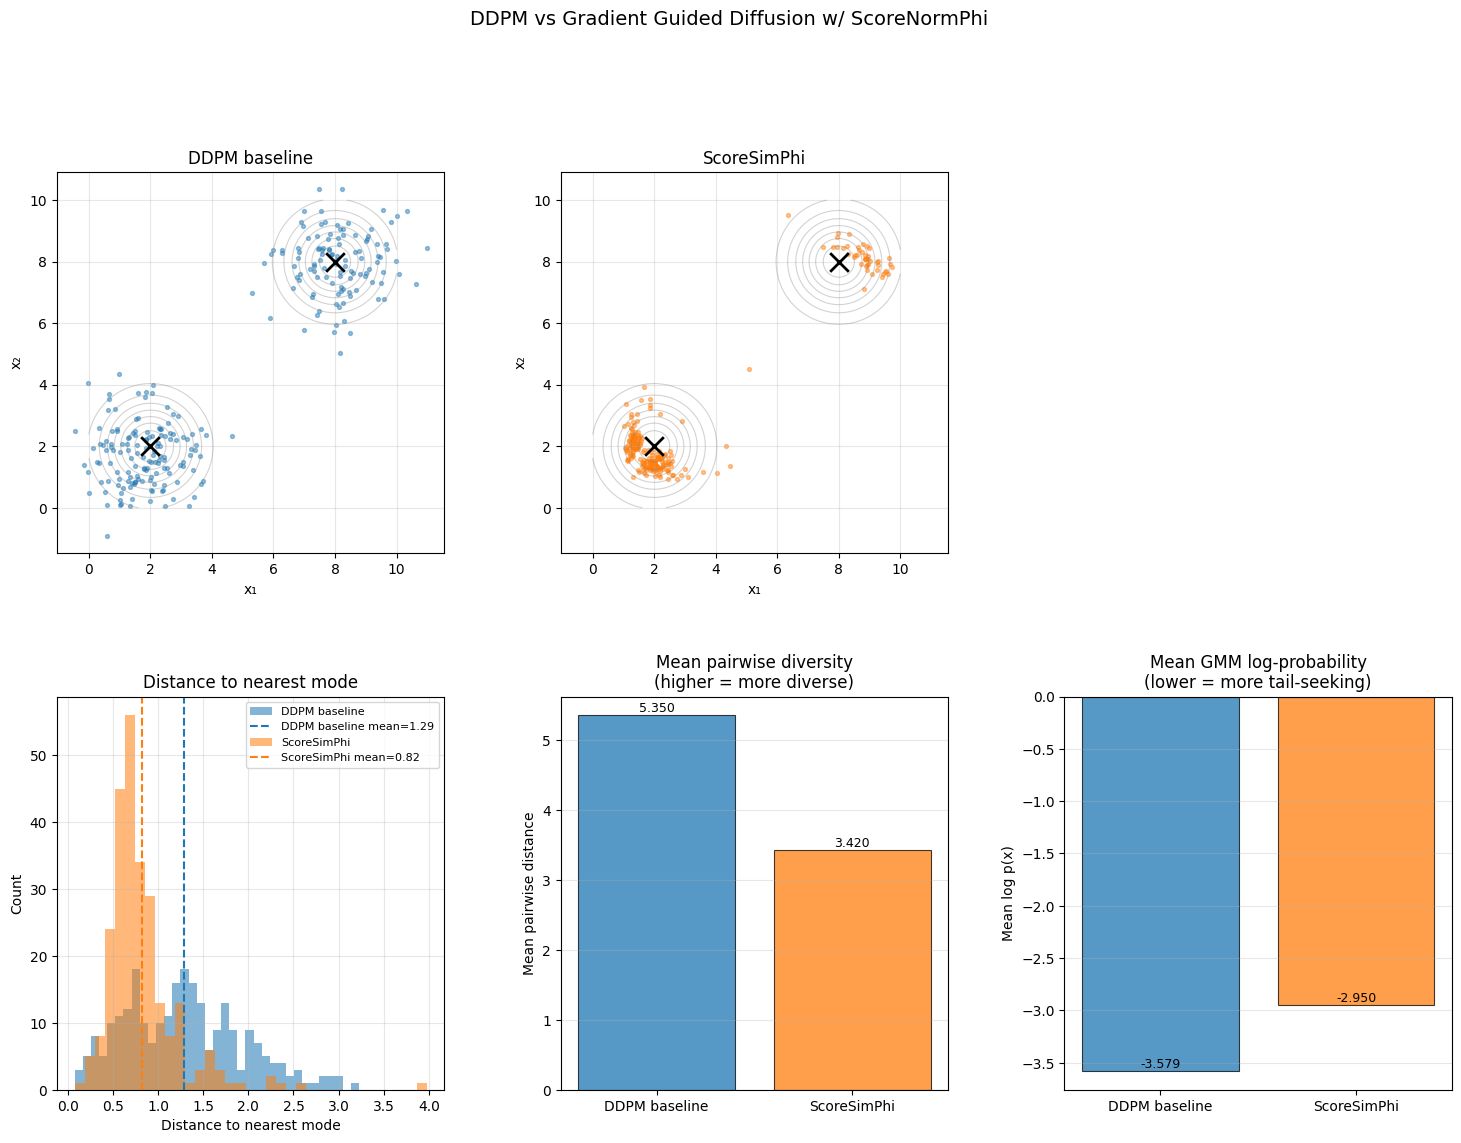

In [23]:
x0_base = torch.load(SAMPLES_DIR / "baselines" /"ddpm_baseline.pt", map_location=DEVICE)

fig = make_comparison_figure(
    sample_dict={
        "DDPM baseline": x0_base,
        "ScoreAlignmentPhi": x0_align,
    },
    gmm=prior_gmm,
    modes=MODE_CENTRES,
    suptitle="DDPM vs Gradient Guided Diffusion w/ ScoreAlignmentPhi ",
)

In [11]:
save_figure(fig, name="comparison_ddpm_vs_score_sim_phi", root=PLOTS_DIR)

Saved figure  -> ../outputs/sampling_results/plots/comparison_ddpm_vs_score_sim_phi.png


## Salience over time in DiversityPhi

  Computing batch salience grid at t=900...
  Computing batch salience grid at t=500...
  Computing batch salience grid at t=250...
  Computing batch salience grid at t=0...


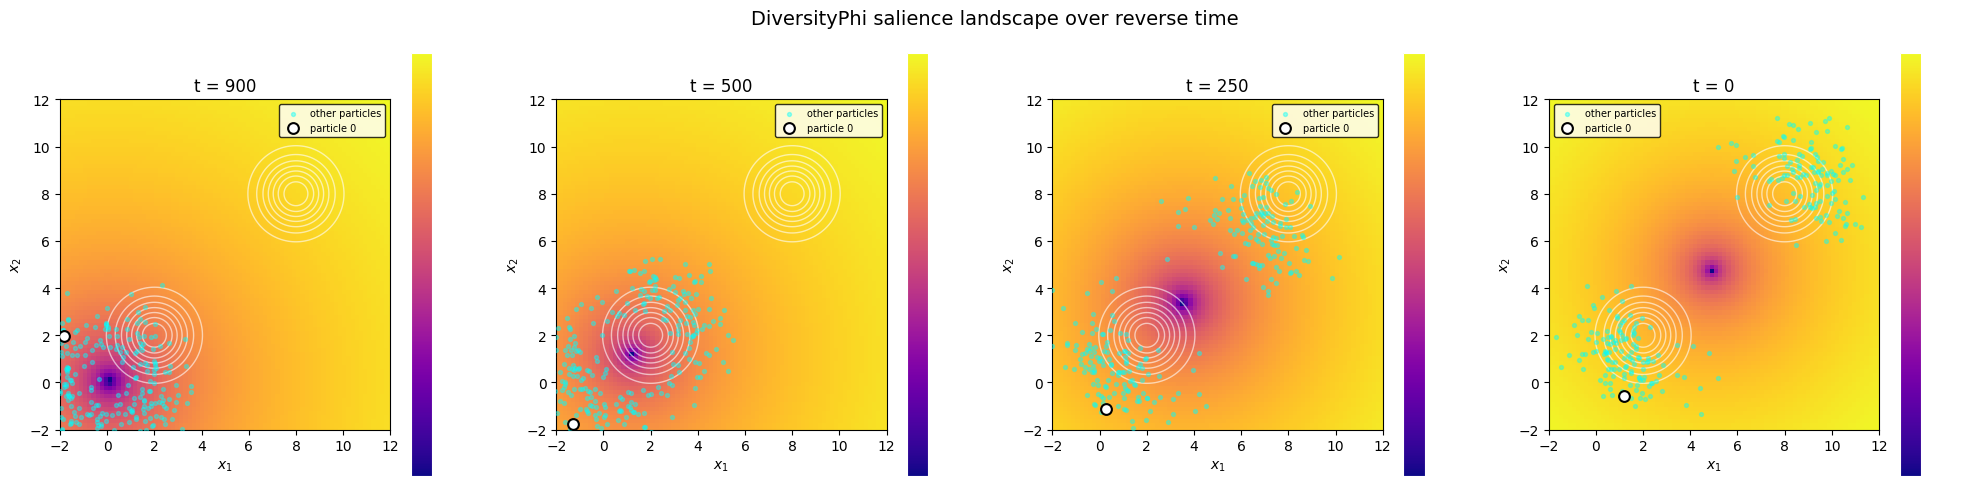

In [66]:
from experiments.visualize_salience import (
    sample_with_trajectory_capture,
    plot_salience_landscape_batch,
)
from salience.phi import DiversityPhi

phi = DiversityPhi()
sampler = SalientSampler(model=model, scheduler=noise_scheduler,
                         phi=phi, device=DEVICE, guidance_frequency=1)

# Run sampling and capture snapshots at selected timesteps
x0, snapshots = sample_with_trajectory_capture(
    sampler=sampler,
    x_T=x_init,
    capture_timesteps=[900, 500, 250, 0],
    guidance_scale=1.0,
    context={},
)

# Plot salience landscape from perspective of particle 0
fig = plot_salience_landscape_batch(
    phi=phi,
    snapshots=snapshots,
    base_context={},
    particle_index=0,
    gmm=prior_gmm,
    suptitle="DiversityPhi salience landscape over reverse time",
    device=DEVICE,
)

  Computing combined figure at t=900...
  Computing combined figure at t=500...
  Computing combined figure at t=250...
  Computing combined figure at t=0...


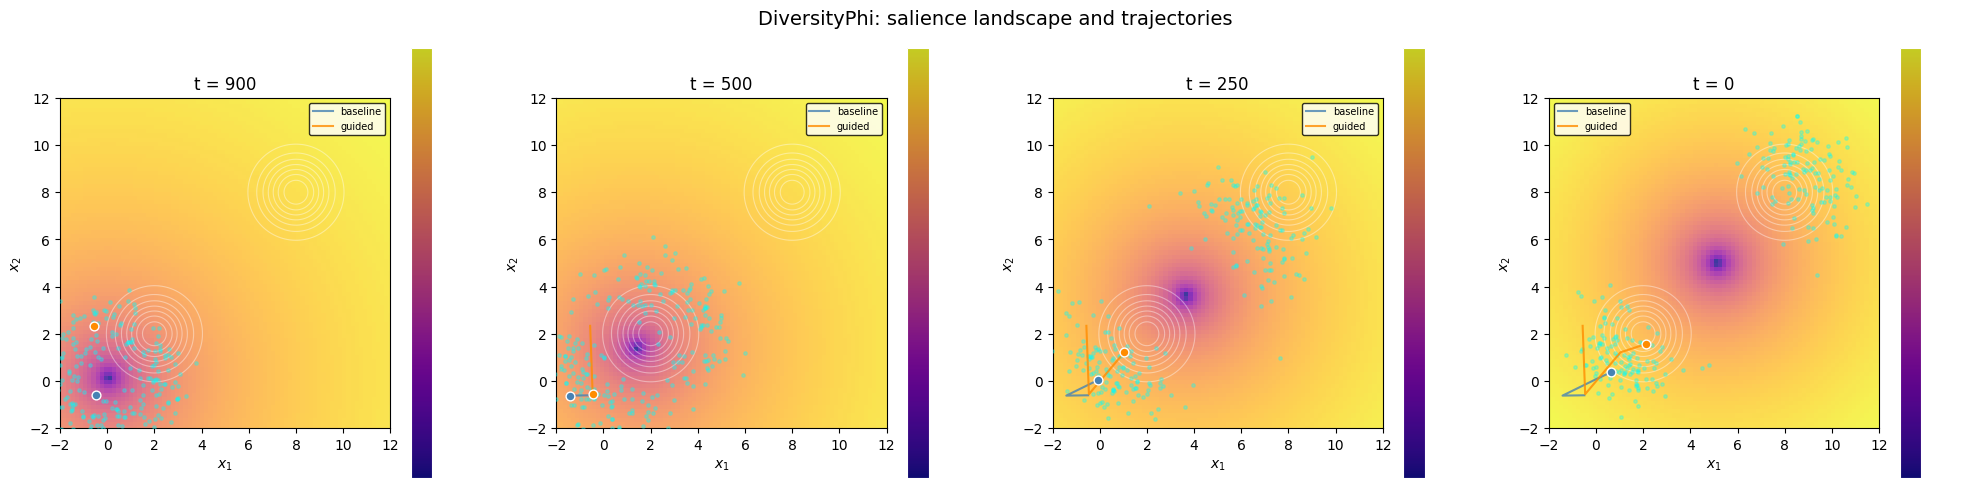

In [67]:
from experiments.visualize_salience import (
    sample_baseline_with_trajectory_capture,
plot_salience_with_trajectories
)

# Capture both trajectories with the same initial noise
x0_base, snaps_base = sample_baseline_with_trajectory_capture(
    model, noise_scheduler, x_init,
    capture_timesteps=[900, 500, 250, 0],
    device=DEVICE,
)

x0_guided, snaps_guided = sample_with_trajectory_capture(
    sampler, x_init,
    capture_timesteps=[900, 500, 250, 0],
    guidance_scale=1.0, context={},
)

# Combined figure
fig = plot_salience_with_trajectories(
    phi=phi, snapshots_baseline=snaps_base,
    snapshots_guided=snaps_guided,
    base_context={}, particle_index=0, gmm=prior_gmm,
    suptitle="DiversityPhi: salience landscape and trajectories",
)

  Computing vector field at t=900...
  Computing vector field at t=500...
  Computing vector field at t=250...
  Computing vector field at t=0...


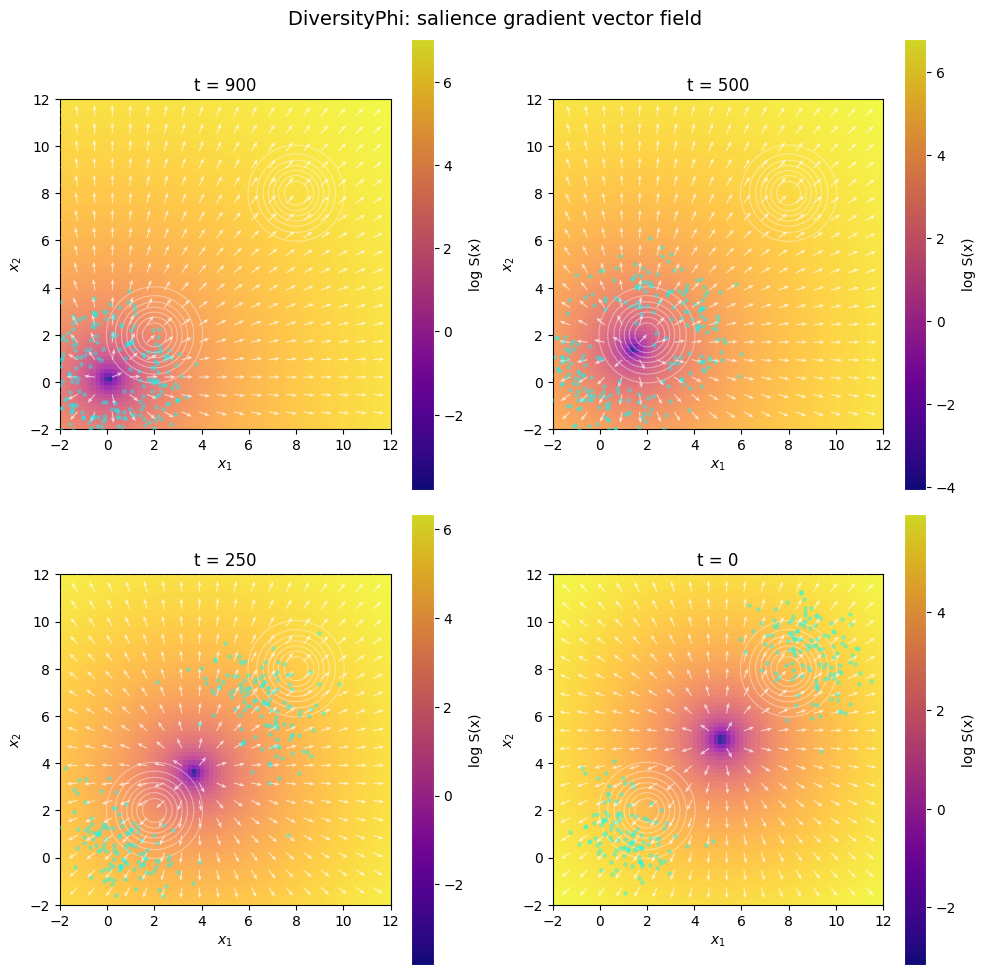

In [68]:
from experiments.visualize_salience import plot_salience_vector_field

phi = DiversityPhi()


# For DiversityPhi or ScoreAlignmentPhi (batch-dependent)
fig = plot_salience_vector_field(
    phi=phi,
    timesteps=[900, 500, 250, 0],
    context={"model": model, "scheduler": noise_scheduler},
    library_snapshots=snaps_guided,  # from sample_with_trajectory_capture
    particle_index=0,
    gmm=prior_gmm,
    suptitle="DiversityPhi: salience gradient vector field",
    device=DEVICE,
)

In [70]:
import torch
from salience.phi import DiversityPhi
import numpy as np

phi = DiversityPhi()

# Asymmetric library — three points NOT symmetrically arranged
lib = torch.tensor([
    [0.0, 0.0],
    [6.0, 1.0],
    [2.0, 5.0],
])
lib_mean = lib.mean(dim=0)
print(f"Library mean: {lib_mean.numpy()}")

test_points = [
    torch.tensor([1.0, 0.0]),
    torch.tensor([0.0, 1.0]),
    torch.tensor([3.0, 3.0]),
    torch.tensor([5.0, 1.0]),
]

for x_query in test_points:
    x_query = x_query.requires_grad_(True)
    X_batch = torch.cat([x_query.unsqueeze(0), lib], dim=0)

    with torch.enable_grad():
        phi_vals = phi.forward_batched(X_batch, t=0, context={})
        phi_query = phi_vals[0].squeeze()
        grad, = torch.autograd.grad(phi_query, x_query)

    # Analytical expected gradient: 2 * (x - lib_mean)
    expected_grad = 2 * (x_query.detach() - lib_mean)

    print(f"\nx={x_query.detach().numpy()}")
    print(f"  computed grad:  {grad.detach().numpy()}")
    print(f"  expected grad:  {expected_grad.numpy()}")
    print(f"  match: {torch.allclose(grad, expected_grad, atol=1e-4)}")

Library mean: [2.6666667 2.       ]

x=[1. 0.]
  computed grad:  [-3.3333335 -4.       ]
  expected grad:  [-3.3333335 -4.       ]
  match: True

x=[0. 1.]
  computed grad:  [-5.3333335 -2.       ]
  expected grad:  [-5.3333335 -2.       ]
  match: True

x=[3. 3.]
  computed grad:  [0.6666667 2.       ]
  expected grad:  [0.6666665 2.       ]
  match: True

x=[5. 1.]
  computed grad:  [ 4.666667 -2.      ]
  expected grad:  [ 4.6666665 -2.       ]
  match: True


## ScoreAlignmentPhi Salience over time

  Computing batch salience grid at t=900...
  Computing batch salience grid at t=500...
  Computing batch salience grid at t=250...
  Computing batch salience grid at t=50...


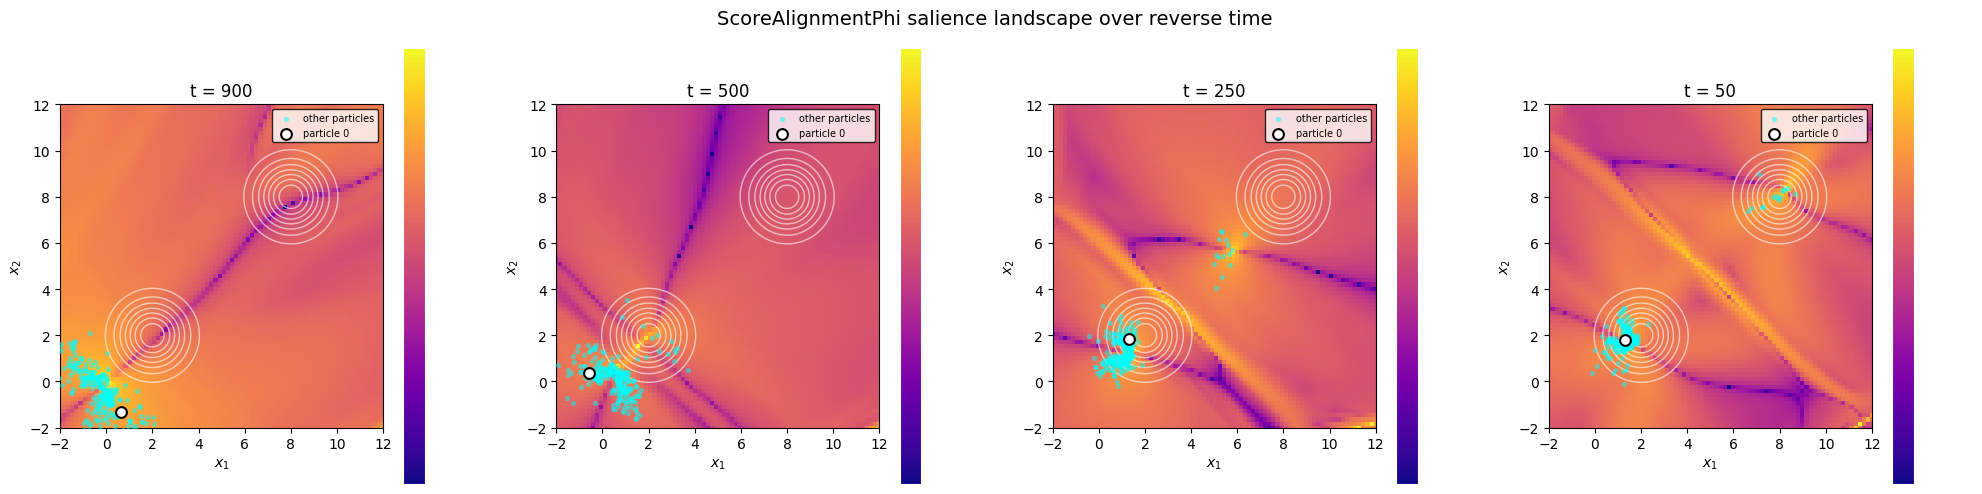

In [55]:
from experiments.visualize_salience import (
    sample_with_trajectory_capture,
    plot_salience_landscape_batch,
)
from salience.phi import ScoreAlignmentPhi

phi = ScoreAlignmentPhi()
sampler = SalientSampler(model=model, scheduler=noise_scheduler,
                         phi=phi, device=DEVICE, guidance_frequency=1)

context = {"model": model, "scheduler": noise_scheduler}

x0, snapshots = sample_with_trajectory_capture(
    sampler=sampler,
    x_T=x_init,
    capture_timesteps=[900, 500, 250, 50],
    guidance_scale=1.0,
    context=context,
)

fig = plot_salience_landscape_batch(
    phi=phi,
    snapshots=snapshots,
    base_context=context,
    particle_index=0,
    gmm=prior_gmm,
    suptitle="ScoreAlignmentPhi salience landscape over reverse time",
    device=DEVICE,
)

  Computing combined figure at t=900...
  Computing combined figure at t=500...
  Computing combined figure at t=250...
  Computing combined figure at t=50...


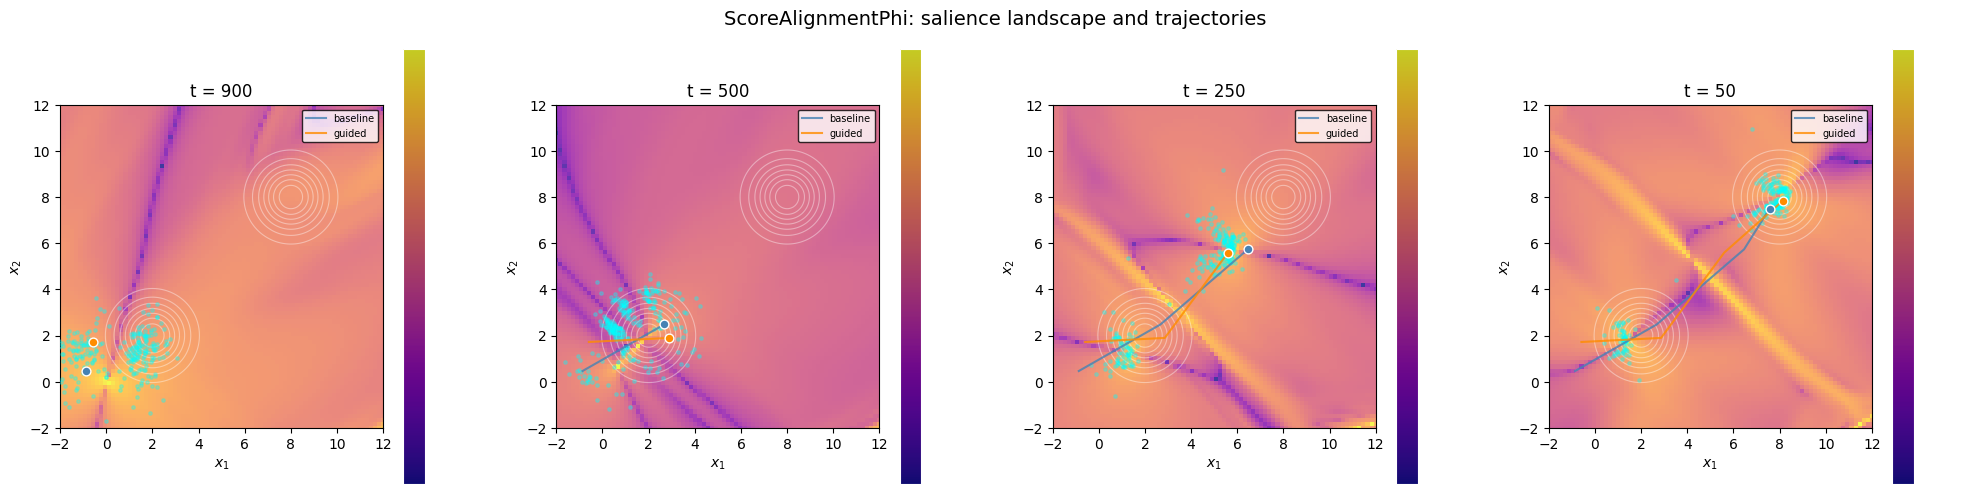

In [56]:
context = {"model": model, "scheduler": noise_scheduler}

x0_base, snaps_base = sample_baseline_with_trajectory_capture(
    model, noise_scheduler, x_init,
    capture_timesteps=[900, 500, 250, 50],
    device=DEVICE,
)

x0_guided, snaps_guided = sample_with_trajectory_capture(
    sampler, x_init,
    capture_timesteps=[900, 500, 250, 50],
    guidance_scale=1.0,
    context=context,
)

fig = plot_salience_with_trajectories(
    phi=phi,
    snapshots_baseline=snaps_base,
    snapshots_guided=snaps_guided,
    base_context=context,
    particle_index=0,
    gmm=prior_gmm,
    suptitle="ScoreAlignmentPhi: salience landscape and trajectories",
    device=DEVICE,
)

  Computing vector field at t=900...
  Computing vector field at t=500...
  Computing vector field at t=250...
  Computing vector field at t=50...


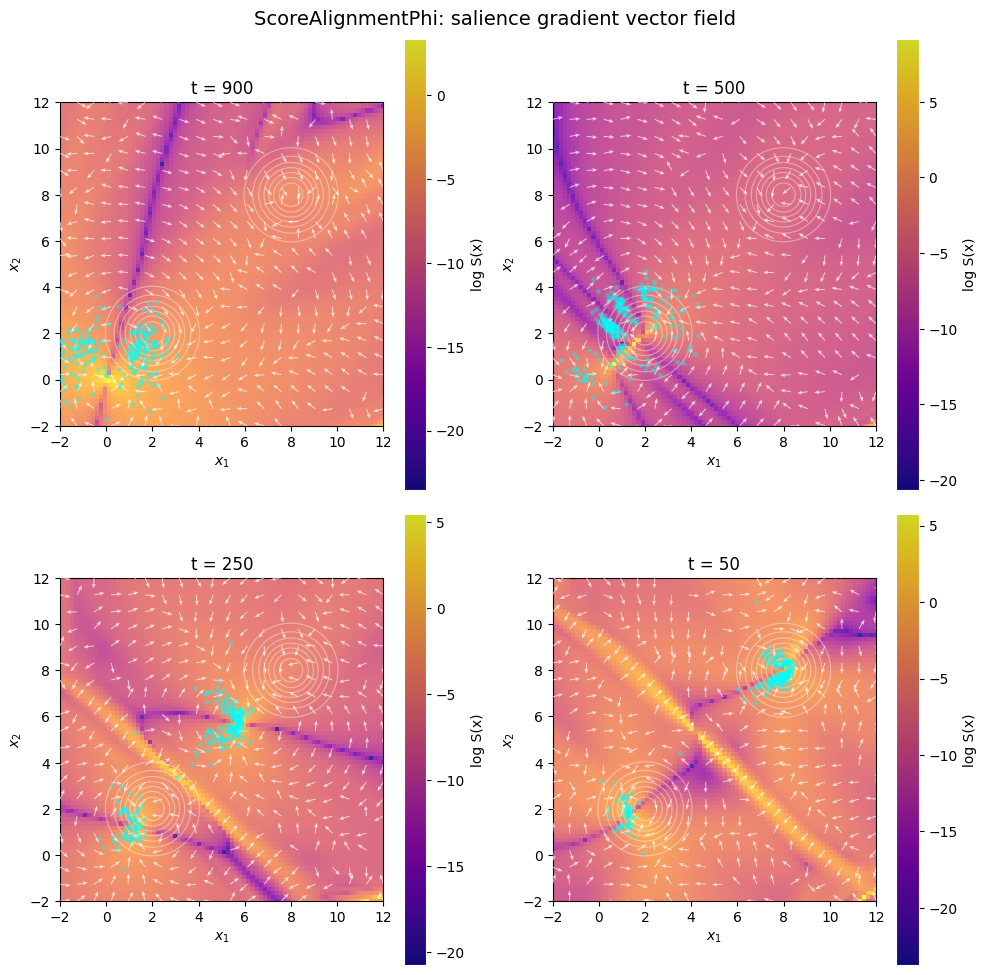

In [57]:
from experiments.visualize_salience import plot_salience_vector_field
from salience.phi import ScoreAlignmentPhi

phi = ScoreAlignmentPhi()
context = {"model": model, "scheduler": noise_scheduler}

fig = plot_salience_vector_field(
    phi=phi,
    timesteps=[900, 500, 250, 50],
    context=context,
    library_snapshots=snaps_guided,
    particle_index=0,
    gmm=prior_gmm,
    suptitle="ScoreAlignmentPhi: salience gradient vector field",
    device=DEVICE,
)